# Spectral Earth Dataset Wrapper Test

In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Adding {project_root} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)


import hydra
from omegaconf import OmegaConf
from hydra.core.global_hydra import GlobalHydra
from hydra.experimental import initialize, compose
from geofm_src.factory import create_dataset


# Set the config directory for OmegaConf to resolve relative paths
config_dir = 'geofm_src/configs/dataset'
# Note: if you run this multiple times, you need to clear the previous initialization
GlobalHydra.instance().clear()

# Initialize with the correct config path
initialize(config_path="../geofm_src/configs/dataset")

Adding /home/ando to sys.path


/home/ando/.conda/envs/fm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:43: UserWarning: hydra.experimental.initialize() is no longer experimental. Use hydra.initialize()
  deprecation_warning(message=message)
/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/experimental/initialize.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  self.delegate = real_initialize(


hydra.experimental.initialize()

## Test Dataset

In [3]:

ds_cfg = compose('tropical_cyclone.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

/home/ando/.conda/envs/fm/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'tropical_cyclone.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
INFO:root:[RegDataAugmentation: train] Sampling channels: [0]
INFO:root:[RegDataAugmentation: train] Sampling channels: [0]


torch.Size([1, 224, 224]) tensor([0.3894])


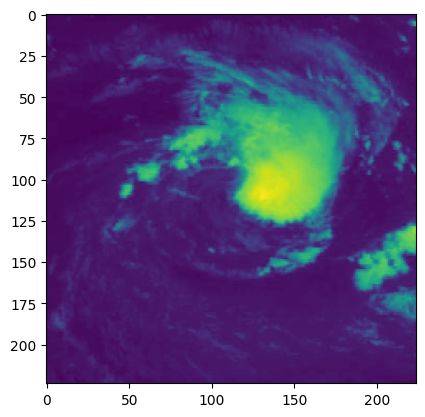

In [8]:
import matplotlib.pyplot as plt
import random

idx = random.randint(0, len(train_ds))
idx = 0
img, label = train_ds[idx]

print(img.shape, label)

if img.shape[0] == 3:
    img = img.permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
else:
    img = img.squeeze(0)
plt.imshow(img)
plt.show()


torch.Size([1, 224, 224]) tensor([0.4639])


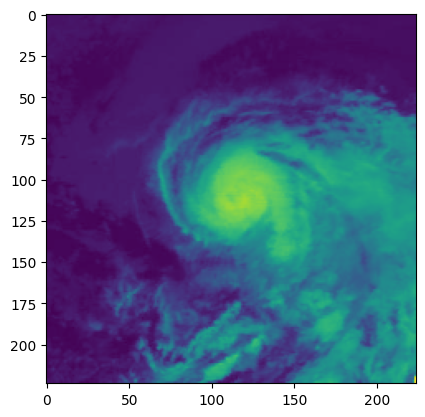

In [19]:
import matplotlib.pyplot as plt
import random

idx = 0
img, label = test_ds[idx]

print(img.shape, label)

if img.shape[0] == 3:
    img = img.permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
else:
    img = img.squeeze(0)
plt.imshow(img)
plt.show()


torch.Size([1, 224, 224]) tensor([-0.6167])


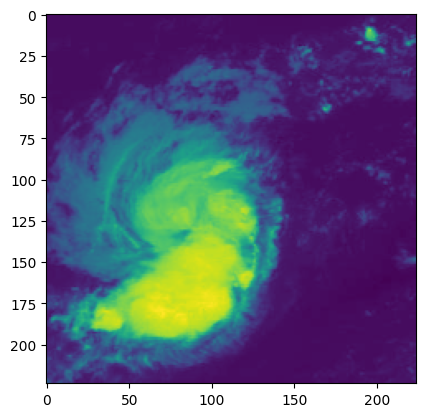

In [26]:
import matplotlib.pyplot as plt
import random

idx = 0
img, label = val_ds[idx]

print(img.shape, label)

if img.shape[0] == 3:
    img = img.permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
else:
    img = img.squeeze(0)
plt.imshow(img)
plt.show()
